# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Dolly Anggara
- **Email:** dollyanggara2003@gmail.com
- **ID Dicoding:** cdcc282d6y0979

## Menentukan Pertanyaan Bisnis

- Bagaimana perbedaan rata-rata dan total jumlah peminjaman sepeda (cnt) antara hari libur (holiday), hari kerja (workingday), dan setiap hari dalam seminggu (weekday)?
- Musim (season) mana yang memiliki rata-rata dan total jumlah peminjaman sepeda (cnt) tertinggi dibandingkan musim lainnya?
- Pada jam (hr) berapa rata-rata jumlah peminjaman sepeda (cnt) mencapai nilai tertinggi dalam satu hari?
- Bagaimana perbedaan rata-rata jumlah peminjaman sepeda antara pengguna casual dan registered pada setiap kondisi cuaca (weathersit)?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
# Memuat dataset harian dari file CSV ke dalam DataFrame
day_df = pd.read_csv('day.csv')

# Menampilkan 5 baris pertama untuk memverifikasi data telah dimuat dengan benar
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
# Memuat dataset rincian per jam dari file CSV
hour_df = pd.read_csv('hour.csv')

# Menampilkan 5 baris pertama untuk melihat rincian kolom data per jam
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### **Insight: Gathering Data**
- **day_df**: DataFrame ini berisi data agregat harian dengan 731 baris. Setiap baris mewakili satu hari dan mencakup informasi krusial seperti kondisi cuaca, suhu yang dinormalisasi, serta jumlah peminjaman yang terbagi menjadi pengguna casual dan registered.
- **hour_df**: DataFrame ini memberikan rincian yang jauh lebih granular dengan 17.379 baris data. Dengan adanya kolom jam (`hr`).

### Assessing Data

### Menilai tabel day

In [4]:
# Mengecek struktur dataset day_df, termasuk jumlah baris, kolom, dan tipe data setiap kolom
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
# Memeriksa apakah ada nilai yang kosong (null/missing values) pada dataset harian
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [6]:
# Menghitung jumlah baris data yang terduplikat dalam dataset harian
print("Jumlah duplikasi data: ", day_df.duplicated().sum())

Jumlah duplikasi data:  0


In [7]:
# Menampilkan ringkasan statistik (mean, std, min, max, dll.) untuk kolom numerik di day_df
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


### Menilai tabel hour

In [8]:
# Mengecek struktur dataset hour_df untuk memahami rincian data per jam
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [9]:
# Memeriksa apakah ada nilai yang kosong pada dataset per jam
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [10]:
# Menghitung jumlah duplikasi data pada dataset per jam
print("Jumlah duplikasi data: ", hour_df.duplicated().sum())

Jumlah duplikasi data:  0


In [11]:
# Menampilkan ringkasan statistik untuk dataset per jam
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


### **Insight: Assessing Data**
- **Tipe Data**: Ditemukan ketidakkonsistenan pada kolom `dteday` yang terbaca sebagai `object`. Ini perlu dikonversi ke tipe `datetime` agar operasi berbasis waktu (seperti ekstraksi bulan atau pengurutan kronologis) dapat dilakukan dengan akurat.
- **Kualitas Data**: Berdasarkan pengecekan `isna().sum()` dan `duplicated()`, dataset ini sangat bersih dant tidak ada nilai yang hilang (missing values) maupun data ganda (duplicates). Hal ini meminimalkan risiko bias dalam analisis.
- **Statistik Deskriptif**: Variabel numerik seperti `temp`, `hum`, dan `windspeed` telah melalui proses normalisasi. Rentang nilai pada `cnt` (peminjaman total) menunjukkan deviasi standar yang cukup besar, mengindikasikan adanya fluktuasi yang dipengaruhi oleh faktor eksternal seperti cuaca atau hari libur.

### Cleaning Data

#### Membersihkan day_df


In [12]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [13]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [14]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [15]:
# Mengubah tipe data kolom 'dteday' menjadi datetime untuk analisis berbasis waktu
datetime_columns = ["dteday"]

for column in datetime_columns:
    day_df[column] = pd.to_datetime(day_df[column])

In [16]:
# Menghapus kolom 'instant', 'atemp', dan 'windspeed' karena redundan atau tidak diperlukan
kolom_dihapus = ['instant', 'atemp', 'windspeed']
day_df.drop(columns=kolom_dihapus, inplace=True)

In [17]:
# Melakukan mapping angka musim ke label teks deskriptif (Spring, Summer, Fall, Winter)
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season_desc'] = day_df['season'].map(season_map)

In [18]:
# Melakukan mapping kode cuaca ke deskripsi kondisi cuaca yang lebih mudah dipahami
weather_map = {1: 'Clear/Partly Cloudy', 2: 'Mist/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Ice'}
day_df['weather_desc'] = day_df['weathersit'].map(weather_map)

In [19]:
# Mengubah angka hari (0-6) menjadi nama hari dalam seminggu
weekday_map = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'}
day_df['weekday_desc'] = day_df['weekday'].map(weekday_map)

In [20]:
# Melakukan mapping angka bulan menjadi singkatan nama bulan
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
day_df['month_desc'] = day_df['mnth'].map(month_map)

In [21]:
# Memberikan label deskriptif untuk status hari libur (Holiday/Not Holiday)
day_df['holiday_desc'] = day_df['holiday'].map({0: 'Not Holiday', 1: 'Holiday'})

In [22]:
# Memberikan label deskriptif untuk status hari kerja vs akhir pekan
day_df['workingday_desc'] = day_df['workingday'].map({0: 'Weekend/Holiday', 1: 'Working Day'})

In [23]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   dteday           731 non-null    datetime64[ns]
 1   season           731 non-null    int64         
 2   yr               731 non-null    int64         
 3   mnth             731 non-null    int64         
 4   holiday          731 non-null    int64         
 5   weekday          731 non-null    int64         
 6   workingday       731 non-null    int64         
 7   weathersit       731 non-null    int64         
 8   temp             731 non-null    float64       
 9   hum              731 non-null    float64       
 10  casual           731 non-null    int64         
 11  registered       731 non-null    int64         
 12  cnt              731 non-null    int64         
 13  season_desc      731 non-null    object        
 14  weather_desc     731 non-null    object   

In [24]:
day_df.head()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,casual,registered,cnt,season_desc,weather_desc,weekday_desc,month_desc,holiday_desc,workingday_desc
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.805833,331,654,985,Spring,Mist/Cloudy,Saturday,Jan,Not Holiday,Weekend/Holiday
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.696087,131,670,801,Spring,Mist/Cloudy,Sunday,Jan,Not Holiday,Weekend/Holiday
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.437273,120,1229,1349,Spring,Clear/Partly Cloudy,Monday,Jan,Not Holiday,Working Day
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.590435,108,1454,1562,Spring,Clear/Partly Cloudy,Tuesday,Jan,Not Holiday,Working Day
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.436957,82,1518,1600,Spring,Clear/Partly Cloudy,Wednesday,Jan,Not Holiday,Working Day


#### Membersihakn hour_df

In [25]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [26]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [27]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [28]:
# Konversi kolom tanggal pada dataset per jam menjadi tipe datetime
datetime_columns = ["dteday"]

for column in datetime_columns:
    hour_df[column] = pd.to_datetime(hour_df[column])

In [29]:
# Menghapus kolom yang tidak diperlukan pada dataset per jam agar konsisten dengan data harian
kolom_dihapus = ['instant', 'atemp', 'windspeed']
hour_df.drop(columns=kolom_dihapus, inplace=True)

In [30]:
# Konversi dteday ke datetime
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [31]:
# Melakukan mapping deskripsi kondisi cuaca untuk data per jam
weather_map = {1: 'Clear/Partly Cloudy', 2: 'Mist/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Ice'}
hour_df['weather_desc'] = hour_df['weathersit'].map(weather_map)

In [32]:
# Melakukan mapping nama hari untuk data per jam
weekday_map = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'}
hour_df['weekday_desc'] = hour_df['weekday'].map(weekday_map)

In [33]:
# Melakukan mapping nama bulan untuk data per jam
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
hour_df['month_desc'] = hour_df['mnth'].map(month_map)

In [34]:
# Memberikan label deskriptif hari libur pada data per jam
hour_df['holiday_desc'] = hour_df['holiday'].map({0: 'Not Holiday', 1: 'Holiday'})

In [35]:
# Memberikan label deskriptif hari kerja pada data per jam
hour_df['workingday_desc'] = hour_df['workingday'].map({0: 'Weekend/Holiday', 1: 'Working Day'})

In [36]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   dteday           17379 non-null  datetime64[ns]
 1   season           17379 non-null  int64         
 2   yr               17379 non-null  int64         
 3   mnth             17379 non-null  int64         
 4   hr               17379 non-null  int64         
 5   holiday          17379 non-null  int64         
 6   weekday          17379 non-null  int64         
 7   workingday       17379 non-null  int64         
 8   weathersit       17379 non-null  int64         
 9   temp             17379 non-null  float64       
 10  hum              17379 non-null  float64       
 11  casual           17379 non-null  int64         
 12  registered       17379 non-null  int64         
 13  cnt              17379 non-null  int64         
 14  weather_desc     17379 non-null  objec

In [37]:
hour_df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,hum,casual,registered,cnt,weather_desc,weekday_desc,month_desc,holiday_desc,workingday_desc
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.81,3,13,16,Clear/Partly Cloudy,Saturday,Jan,Not Holiday,Weekend/Holiday
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.80,8,32,40,Clear/Partly Cloudy,Saturday,Jan,Not Holiday,Weekend/Holiday
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.80,5,27,32,Clear/Partly Cloudy,Saturday,Jan,Not Holiday,Weekend/Holiday
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.75,3,10,13,Clear/Partly Cloudy,Saturday,Jan,Not Holiday,Weekend/Holiday
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.75,0,1,1,Clear/Partly Cloudy,Saturday,Jan,Not Holiday,Weekend/Holiday


### **Insight: Cleaning Data**
- **Efisiensi Struktur**: Kolom `instant` (indeks baris) dan `atemp` (suhu perasaan) dihapus. `atemp` dihapus karena memiliki korelasi yang sangat tinggi dengan `temp`, sehingga cukup menggunakan satu variabel suhu untuk menghindari redundansi.
- **Pemberian Label Deskriptif**: Proses mapping dilakukan untuk mengubah kode angka (seperti season 1, 2, 3, 4) menjadi label teks yang jelas ('Spring', 'Summer', dsb). Langkah ini sangat krusial agar hasil visualisasi dan tabel agregasi nantinya dapat langsung dipahami oleh pembaca tanpa perlu merujuk pada kamus data.
- **Konsistensi**: Transformasi yang sama diterapkan pada kedua dataset (`day` dan `hour`) untuk memastikan bahwa saat digabungkan nanti, tidak ada konflik label atau perbedaan format.

## Exploratory Data Analysis (EDA)

### Explore day_df

In [38]:
day_df.sample(5)

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,casual,registered,cnt,season_desc,weather_desc,weekday_desc,month_desc,holiday_desc,workingday_desc
147,2011-05-28,2,0,5,0,6,0,1,0.655833,0.729583,2001,2757,4758,Summer,Clear/Partly Cloudy,Saturday,May,Not Holiday,Weekend/Holiday
58,2011-02-28,1,0,2,0,1,1,2,0.407273,0.876364,81,1365,1446,Spring,Mist/Cloudy,Monday,Feb,Not Holiday,Working Day
323,2011-11-20,4,0,11,0,0,0,2,0.463333,0.684583,787,2733,3520,Winter,Mist/Cloudy,Sunday,Nov,Not Holiday,Weekend/Holiday
536,2012-06-20,2,1,6,0,3,1,1,0.782500,0.592083,872,5339,6211,Summer,Clear/Partly Cloudy,Wednesday,Jun,Not Holiday,Working Day
451,2012-03-27,2,1,3,0,2,1,1,0.323333,0.290000,531,4571,5102,Summer,Clear/Partly Cloudy,Tuesday,Mar,Not Holiday,Working Day


In [39]:
day_df.describe(include="all")

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,casual,registered,cnt,season_desc,weather_desc,weekday_desc,month_desc,holiday_desc,workingday_desc
count,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731,731,731,731,731,731
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,3,7,12,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,Clear/Partly Cloudy,Saturday,Jan,Not Holiday,Working Day
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,188,463,105,62,710,500
mean,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.627894,848.176471,3656.172367,4504.348837,NaN,NaN,NaN,NaN,NaN,NaN
min,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.000000,2.000000,20.000000,22.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.520000,315.500000,2497.000000,3152.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.626667,713.000000,3662.000000,4548.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.730209,1096.000000,4776.500000,5956.000000,NaN,NaN,NaN,NaN,NaN,NaN
max,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.972500,3410.000000,6946.000000,8714.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
# Memeriksa keunikan kolom instant (sudah dihapus, cek kolom lain)
day_df.dteday.is_unique

True

In [75]:
# Melakukan agregasi data untuk melihat perbandingan statistik peminjaman (min, max, mean) antar musim
# Ini membantu menjawab pertanyaan musim mana yang paling populer bagi pengguna
day_df.groupby("season_desc").agg({
    "cnt": ["max", "min", "mean", "std"],
    "casual": ["max", "min", "mean", "std"],
    "registered": ["max", "min", "mean", "std"]
})

cnt                                 casual                    \
              max   min         mean          std    max  min         mean   
season_desc                                                                  
Fall         8714  1115  5644.303191  1459.800381   3160  118  1202.611702   
Spring       7836   431  2604.132597  1399.942119   3155    9   334.928177   
Summer       8362   795  4992.331522  1695.977235   3410  120  1106.097826   
Winter       8555    22  4728.162921  1699.615261   3031    2   729.112360   

                        registered                                 
                    std        max  min         mean          std  
season_desc                                                        
Fall         595.975032       6917  889  4441.691489  1304.626949  
Spring       387.655561       5315  416  2269.204420  1200.269751  
Summer       737.590829       6456  674  3886.233696  1353.375628  
Winter       606.318118       6946   20  3999.050562  1444.782557

In [76]:
# Menganalisis pengaruh kondisi cuaca terhadap jumlah total peminjaman harian
day_df.groupby("weather_desc").cnt.agg(["max", "min", "mean", "std"])

,max,min,mean,std
weather_desc,,,,
Clear/Partly Cloudy,8714,431,4876.786177,1879.483989
Light Snow/Rain,4639,22,1803.285714,1240.284449
Mist/Cloudy,8362,605,4035.862348,1809.109918


In [77]:
# Melihat tren rata-rata peminjaman berdasarkan hari dalam seminggu untuk mengidentifikasi hari tersibuk
day_df.groupby("weekday_desc").cnt.mean().sort_values(ascending=False)

,cnt
weekday_desc,
Friday,4690.288462
Thursday,4667.259615
Saturday,4550.542857
Wednesday,4548.538462
Tuesday,4510.663462
Monday,4338.123810
Sunday,4228.828571


In [44]:
# Analisis berdasarkan holiday
day_df.groupby("holiday_desc").cnt.agg(["max", "min", "mean", "std"])

,max,min,mean,std
holiday_desc,,,,
Holiday,7403,1000,3735.000000,2103.350660
Not Holiday,8714,22,4527.104225,1929.013947


In [45]:
# Analisis berdasarkan workingday
day_df.groupby("workingday_desc").cnt.agg(["max", "min", "mean", "std"])

,max,min,mean,std
workingday_desc,,,,
Weekend/Holiday,8714,605,4330.168831,2052.141245
Working Day,8362,22,4584.820000,1878.415583


In [46]:
# Analisis berdasarkan bulan
day_df.groupby("mnth").cnt.mean().sort_values(ascending=False)

,cnt
mnth,
6,5772.366667
9,5766.516667
8,5664.419355
7,5563.677419
5,5349.774194
10,5199.225806
4,4484.900000
11,4247.183333
3,3692.258065


### Explore hour_df

In [47]:
hour_df.sample(5)

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,hum,casual,registered,cnt,weather_desc,weekday_desc,month_desc,holiday_desc,workingday_desc
7147,2011-10-30,4,0,10,10,0,0,0,1,0.32,0.61,53,125,178,Clear/Partly Cloudy,Sunday,Oct,Not Holiday,Weekend/Holiday
12025,2012-05-21,2,1,5,6,0,1,1,3,0.56,0.88,3,76,79,Light Snow/Rain,Monday,May,Not Holiday,Working Day
14826,2012-09-14,3,1,9,23,0,5,1,1,0.62,0.78,27,168,195,Clear/Partly Cloudy,Friday,Sep,Not Holiday,Working Day
14218,2012-08-20,3,1,8,15,0,1,1,1,0.72,0.54,102,207,309,Clear/Partly Cloudy,Monday,Aug,Not Holiday,Working Day
9912,2012-02-23,1,1,2,1,0,4,1,2,0.44,0.58,3,12,15,Mist/Cloudy,Thursday,Feb,Not Holiday,Working Day


In [48]:
hour_df.describe(include="all")

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,hum,casual,registered,cnt,weather_desc,weekday_desc,month_desc,holiday_desc,workingday_desc
count,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379,17379,17379,17379,17379
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,7,12,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Clear/Partly Cloudy,Saturday,Jul,Not Holiday,Working Day
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11413,2512,1488,16879,11865
mean,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.627229,35.676218,153.786869,189.463088,NaN,NaN,NaN,NaN,NaN
min,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.480000,4.000000,34.000000,40.000000,NaN,NaN,NaN,NaN,NaN
50%,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.630000,17.000000,115.000000,142.000000,NaN,NaN,NaN,NaN,NaN
75%,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.780000,48.000000,220.000000,281.000000,NaN,NaN,NaN,NaN,NaN
max,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,367.000000,886.000000,977.000000,NaN,NaN,NaN,NaN,NaN


In [49]:
hour_df.dteday.is_unique

False

In [78]:
# Analisis mendalam per jam untuk melihat pola penggunaan harian
# Sangat berguna untuk mengidentifikasi jam sibuk (peak hours) bagi pengguna casual vs registered
hour_df.groupby("hr").agg({
    "cnt": ["max", "min", "mean", "std"],
    "casual": ["max", "min", "mean", "std"],
    "registered": ["max", "min", "mean", "std"]
})

cnt                             casual                            \
    max min        mean         std    max min       mean        std   
hr                                                                     
0   283   2   53.898072   42.307910     68   0  10.158402  10.667953   
1   168   1   33.375691   33.538727     49   0   6.504144   7.735334   
2   132   1   22.869930   26.578642     44   0   4.772028   6.514780   
3    79   1   11.727403   13.239190     26   0   2.715925   4.315795   
4    28   1    6.352941    4.143818     13   0   1.253945   1.887669   
5    66   1   19.889819   13.200765     16   0   1.411437   1.790581   
6   213   1   76.044138   55.084348     19   0   4.161379   3.691509   
7   596   1  212.064649  161.441936     40   0  11.055021   8.356205   
8   839   5  359.011004  235.189285     69   0  21.679505  13.741229   
9   426  14  219.309491   93.703458    142   0  30.891334  24.472856   
10  539   8  173.668501  102.205413    209   0  46.477304  41.346206   
11  663  10  208.143054  127.495536    268   0  59.540578  54.481788   
12  776   3  253.315934  145.081134    362   0  68.293956  64.394237   
13  760  11  253.661180  148.107657    355   0  72.308642  69.819228   
14  750  12  240.949246  147.271574    361   0  75.567901  71.599225   
15  750   7  251.233196  144.632541    357   0  74.905350  70.289359   
16  783  11  311.983562  148.682618    367   0  73.745205  67.015206   
17  976  15  461.452055  232.656611    347   0  74.273973  61.491021   
18  977  23  425.510989  224.639304    266   0  61.120879  50.981553   
19  743  11  311.523352  161.050359    230   0  48.770604  42.328913   
20  567  11  226.030220  119.670164    237   0  36.233516  32.103347   
21  584   6  172.314560   89.788893    222   0  28.255495  25.378252   
22  502   9  131.335165   69.937782    175   0  22.252747  20.450211   
23  256   2   87.831044   50.846889     71   0  15.199176  13.804596   

   registered                              
          max min        mean         std  
hr                                         
0         234   0   43.739669   34.019585  
1         139   0   26.871547   27.344153  
2         104   0   18.097902   21.303895  
3          61   0    9.011478    9.743691  
4          22   0    5.098996    3.134479  
5          64   0   18.478382   12.674751  
6         203   0   71.882759   53.535307  
7         572   1  201.009629  157.120459  
8         808   4  337.331499  229.698404  
9         399   6  188.418157   84.633490  
10        351   8  127.191197   66.281668  
11        446   5  148.602476   79.090301  
12        526   3  185.021978   89.240873  
13        491   9  181.352538   87.424775  
14        502  12  165.381344   84.055205  
15        456   4  176.327846   84.488219  
16        481   8  238.238356  103.765726  
17        885  14  387.178082  211.676303  
18        886  20  364.390110  203.599896  
19        662  11  262.752747  138.708622  
20        461   8  189.796703  100.293791  
21        362   6  144.059066   73.149848  
22        327   5  109.082418   55.252765  
23        220   2   72.631868   40.446431

In [51]:
# Analisis berdasarkan weathersit
hour_df.groupby("weather_desc").cnt.mean().sort_values(ascending=False)

,cnt
weather_desc,
Clear/Partly Cloudy,204.869272
Mist/Cloudy,175.165493
Light Snow/Rain,111.579281
Heavy Rain/Ice,74.333333


In [52]:
# Analisis berdasarkan weekday
hour_df.groupby("weekday_desc").cnt.mean().sort_values(ascending=False)

,cnt
weekday_desc,
Thursday,196.436665
Friday,196.135907
Tuesday,191.238891
Wednesday,191.130505
Saturday,190.209793
Monday,183.744655
Sunday,177.468825


In [53]:
# Analisis berdasarkan holiday
hour_df.groupby("holiday_desc").cnt.mean()

,cnt
holiday_desc,
Holiday,156.87000
Not Holiday,190.42858


In [54]:
# Analisis berdasarkan workingday
hour_df.groupby("workingday_desc").cnt.mean()

,cnt
workingday_desc,
Weekend/Holiday,181.405332
Working Day,193.207754


### Explore hour_df dan day_df

In [79]:
# Menggabungkan dataset harian (day_df) dan per jam (hour_df) menjadi satu DataFrame
# ignore_index=True digunakan agar indeks direset dari 0, sort=False untuk mempertahankan urutan kolom yang ada
all_df = pd.concat([day_df, hour_df], ignore_index=True, sort=False)

# Menampilkan 5 baris pertama untuk memastikan penggabungan berhasil dan struktur data benar
display(all_df.head())

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,casual,registered,cnt,season_desc,weather_desc,weekday_desc,month_desc,holiday_desc,workingday_desc,hr
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.805833,331,654,985,Spring,Mist/Cloudy,Saturday,Jan,Not Holiday,Weekend/Holiday,NaN
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.696087,131,670,801,Spring,Mist/Cloudy,Sunday,Jan,Not Holiday,Weekend/Holiday,NaN
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.437273,120,1229,1349,Spring,Clear/Partly Cloudy,Monday,Jan,Not Holiday,Working Day,NaN
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.590435,108,1454,1562,Spring,Clear/Partly Cloudy,Tuesday,Jan,Not Holiday,Working Day,NaN
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.436957,82,1518,1600,Spring,Clear/Partly Cloudy,Wednesday,Jan,Not Holiday,Working Day,NaN


In [56]:
# Menghitung rata-rata peminjaman (cnt) per musim (season_desc) dari yang tertinggi
all_df.groupby(by="season_desc").cnt.mean().sort_values(ascending=False)

,cnt
season_desc,
Fall,5644.303191
Summer,4992.331522
Winter,4728.162921
Spring,2604.132597


In [57]:
# Menganalisis pengaruh kondisi cuaca (weather_desc) terhadap rata-rata peminjaman sepeda
all_df.groupby(by="weather_desc").cnt.mean().sort_values(ascending=False)

,cnt
weather_desc,
Clear/Partly Cloudy,387.009515
Mist/Cloudy,374.203715
Light Snow/Rain,136.250000
Heavy Rain/Ice,74.333333


In [58]:
# Melihat pola rata-rata peminjaman sepeda berdasarkan hari dalam seminggu (weekday_desc)
all_df.groupby(by="weekday_desc").cnt.mean().sort_values(ascending=False)

,cnt
weekday_desc,
Thursday,377.005825
Friday,376.526438
Tuesday,366.921392
Wednesday,366.846064
Saturday,365.156286
Monday,352.556502
Sunday,340.642117


In [59]:
# Membandingkan rata-rata peminjaman antara hari libur (holiday) dan hari biasa
all_df.groupby(by="holiday_desc").cnt.mean().sort_values(ascending=False)

,cnt
holiday_desc,
Not Holiday,365.483427
Holiday,301.094050


In [60]:
# Menganalisis rata-rata peminjaman pada hari kerja dibandingkan akhir pekan/libur
all_df.groupby(by="workingday_desc").cnt.mean().sort_values(ascending=False)

,cnt
workingday_desc,
Working Day,370.790133
Weekend/Holiday,348.222454


### **Insight: Exploratory Data Analysis (EDA)**
- **Pola Penggunaan**: Terdapat perbedaan perilaku yang kontras antara hari kerja dan akhir pekan. Pada hari kerja, lonjakan terjadi di jam sibuk pagi dan sore, sedangkan di akhir pekan penggunaan lebih merata sepanjang siang hari. Ini menunjukkan sepeda berfungsi ganda: sebagai moda komuter dan sarana rekreasi.
- **Dinamika Musiman**: Musim Gugur (`Fall`) merupakan periode emas dengan rata-rata peminjaman tertinggi. Kondisi suhu yang sejuk kemungkinan besar menjadi faktor pendorong utama dibandingkan musim ekstrem seperti musim dingin (`Spring/Winter`).
- **Sensitivitas Cuaca**: Cuaca buruk (hujan/salju) memiliki dampak negatif yang lebih drastis pada pengguna casual dibandingkan pengguna registered. Pengguna terdaftar cenderung tetap bersepeda meski cuaca kurang mendukung, kemungkinan karena keterikatan pada rutinitas transportasi harian.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perbedaan rata-rata dan total jumlah peminjaman sepeda (cnt) antara hari libur (holiday), hari kerja (workingday), dan setiap hari dalam seminggu (weekday)?

In [61]:
# Rata-rata peminjaman berdasarkan holiday
all_df.groupby('holiday_desc')['cnt'].agg(['mean', 'sum'])

,mean,sum
holiday_desc,,
Holiday,301.094050,156870
Not Holiday,365.483427,6428488


In [62]:
# Rata-rata peminjaman berdasarkan workingday
all_df.groupby('workingday_desc')['cnt'].agg(['mean', 'sum'])

,mean,sum
workingday_desc,,
Weekend/Holiday,348.222454,2000538
Working Day,370.790133,4584820


In [63]:
# Rata-rata peminjaman berdasarkan weekday
all_df.groupby('weekday_desc')['cnt'].agg(['mean', 'sum']).sort_values('mean', ascending=False)

,mean,sum
weekday_desc,,
Thursday,377.005825,970790
Friday,376.526438,975580
Tuesday,366.921392,938218
Wednesday,366.846064,946096
Saturday,365.156286,955614
Monday,352.556502,911006
Sunday,340.642117,888054


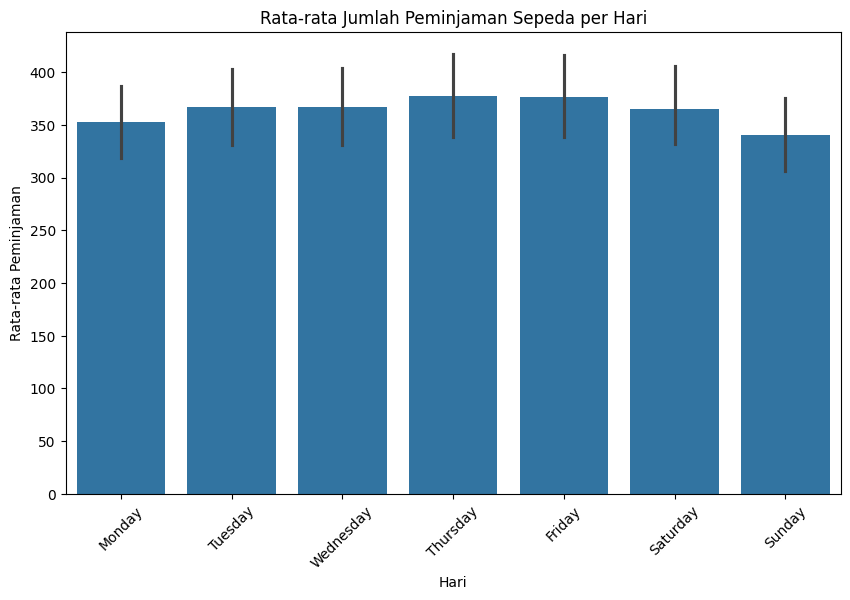

In [64]:
# Membuat visualisasi perbandingan rata-rata peminjaman sepeda per hari dalam seminggu
# Menggunakan barplot untuk melihat hari mana yang paling populer
plt.figure(figsize=(10,6))
sns.barplot(data=all_df, x='weekday_desc', y='cnt', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Rata-rata Jumlah Peminjaman Sepeda per Hari')
plt.xlabel('Hari')
plt.ylabel('Rata-rata Peminjaman')
plt.xticks(rotation=45)
plt.show()

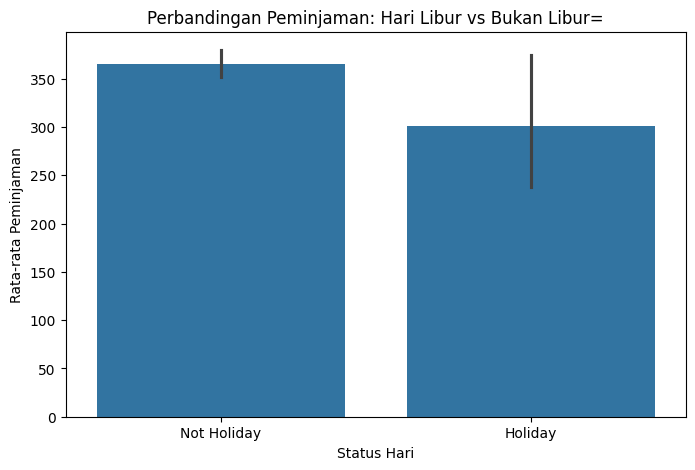

In [65]:
# Visualisasi perbandingan holiday vs non-holiday menggunakan all_df
plt.figure(figsize=(8,5))
sns.barplot(data=all_df, x='holiday_desc', y='cnt')
plt.title('Perbandingan Peminjaman: Hari Libur vs Bukan Libur=')
plt.xlabel('Status Hari')
plt.ylabel('Rata-rata Peminjaman')
plt.show()

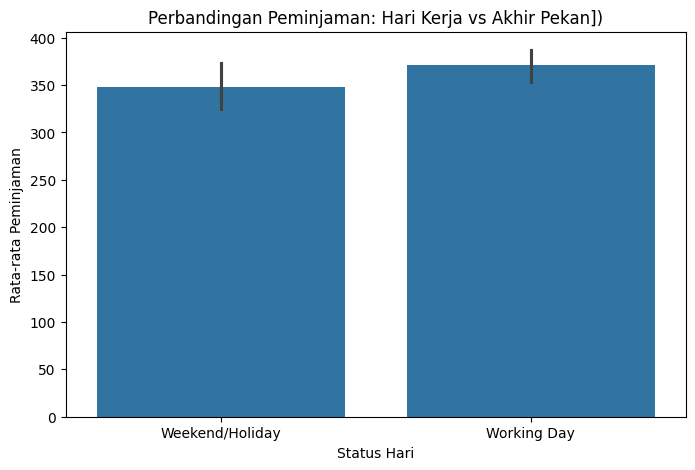

In [66]:
# Visualisasi perbandingan workingday vs non-workingday menggunakan all_df
plt.figure(figsize=(8,5))
sns.barplot(data=all_df, x='workingday_desc', y='cnt')
plt.title('Perbandingan Peminjaman: Hari Kerja vs Akhir Pekan])')
plt.xlabel('Status Hari')
plt.ylabel('Rata-rata Peminjaman')
plt.show()

Berdasarkan grafik di atas, rata-rata peminjaman pada hari kerja sedikit lebih tinggi dibandingkan akhir pekan atau hari libur, menunjukkan penggunaan sepeda yang signifikan untuk kebutuhan mobilitas harian. Hari Kamis dan Jumat tercatat sebagai hari dengan volume peminjaman tertinggi.

### Pertanyaan 2: Musim (season) mana yang memiliki rata-rata dan total jumlah peminjaman sepeda (cnt) tertinggi dibandingkan musim lainnya?

In [67]:
# Rata-rata dan total peminjaman berdasarkan season
all_df.groupby('season_desc')['cnt'].agg(['mean', 'sum']).sort_values('mean', ascending=False)

,mean,sum
season_desc,,
Fall,5644.303191,1061129
Summer,4992.331522,918589
Winter,4728.162921,841613
Spring,2604.132597,471348


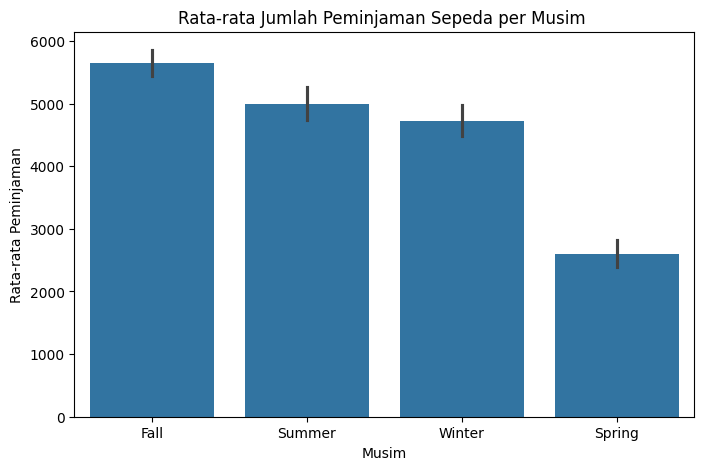

In [68]:
# Visualisasi rata-rata peminjaman per season menggunakan all_df
plt.figure(figsize=(8,5))
sns.barplot(data=all_df, x='season_desc', y='cnt', order=['Fall', 'Summer', 'Winter', 'Spring'])
plt.title('Rata-rata Jumlah Peminjaman Sepeda per Musim ')
plt.xlabel('Musim')
plt.ylabel('Rata-rata Peminjaman')
plt.show()

Grafik menunjukkan bahwa Musim Gugur (Fall) menjadi periode dengan puncak peminjaman tertinggi karena didukung oleh suhu yang nyaman bagi pesepeda. Sebaliknya, Musim Semi (Spring) mencatatkan angka terendah yang kemungkinan dipengaruhi oleh faktor cuaca transisi.

### Pertanyaan 3: Pertanyaan 3: Pada jam (hr) berapa rata-rata jumlah peminjaman sepeda (cnt) mencapai nilai tertinggi dalam satu hari?


In [69]:
# Rata-rata peminjaman per jam
all_df.groupby('hr')['cnt'].mean().sort_values(ascending=False).head(10)

,cnt
hr,
17.0,461.452055
18.0,425.510989
8.0,359.011004
16.0,311.983562
19.0,311.523352
13.0,253.661180
12.0,253.315934
15.0,251.233196
14.0,240.949246


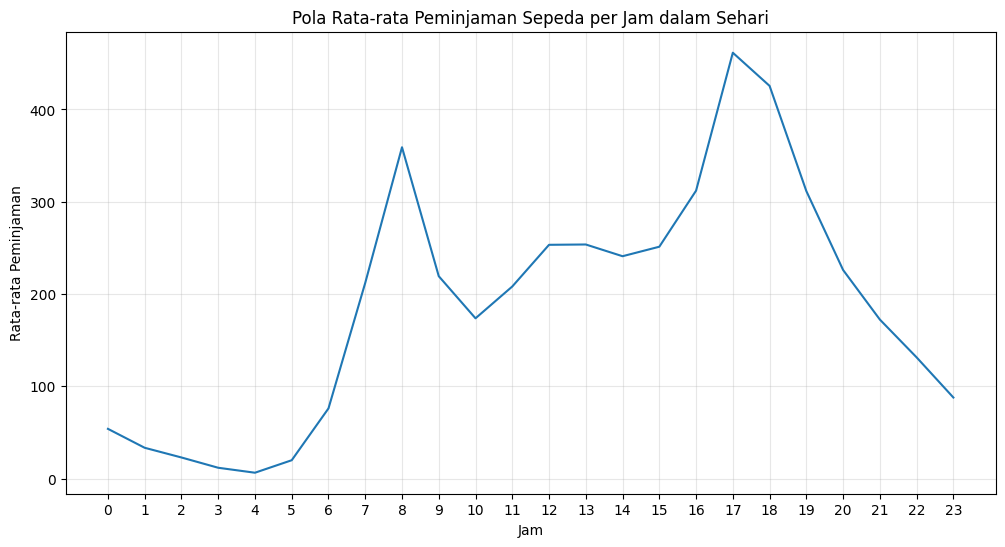

In [70]:
# Membuat diagram garis untuk melihat fluktuasi peminjaman sepeda setiap jam dalam sehari
# Tujuannya untuk mengidentifikasi 'peak hours' atau jam sibuk penggunaan sepeda
plt.figure(figsize=(12,6))
sns.lineplot(data=hour_df, x='hr', y='cnt', errorbar=None)
plt.title('Pola Rata-rata Peminjaman Sepeda per Jam dalam Sehari')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Peminjaman')
plt.xticks(range(0,24))
plt.grid(True, alpha=0.3)
plt.show()

Pola peminjaman harian menunjukkan lonjakan tajam pada pukul 08:00 pagi dan 17:00-18:00 sore, yang selaras dengan jam berangkat dan pulang kerja. Pada akhir pekan, distribusi penggunaan cenderung lebih merata di siang hari tanpa adanya puncak yang ekstrem.

### Pertanyaan 4: Pertanyaan 4: Bagaimana perbedaan rata-rata jumlah peminjaman sepeda antara pengguna casual dan registered pada setiap kondisi cuaca (weathersit)?

In [72]:
# Rata-rata peminjaman casual dan registered berdasarkan kondisi cuaca
all_df.groupby('weather_desc')[['casual', 'registered']].mean().sort_values('registered', ascending=False)

,casual,registered
weather_desc,,
Mist/Cloudy,63.505949,310.697767
Clear/Partly Cloudy,76.548585,310.460930
Light Snow/Rain,18.526389,117.723611
Heavy Rain/Ice,2.666667,71.666667


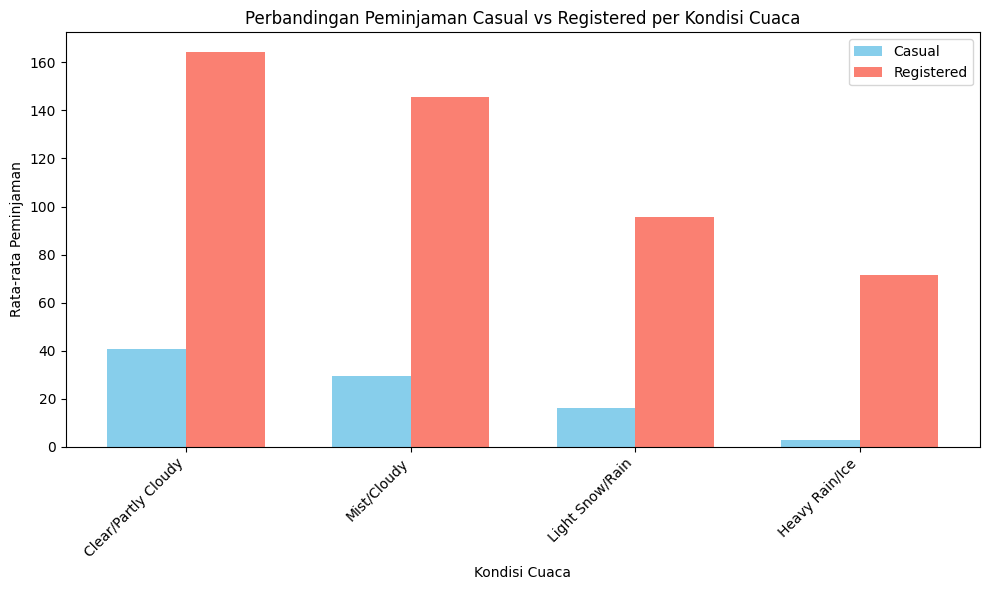

In [73]:
# Visualisasi perbandingan casual vs registered per kondisi cuaca
plt.figure(figsize=(10,6))
weather_order = ['Clear/Partly Cloudy', 'Mist/Cloudy', 'Light Snow/Rain', 'Heavy Rain/Ice']
x = np.arange(len(weather_order))
width = 0.35

casual_mean = hour_df.groupby('weather_desc')['casual'].mean().reindex(weather_order)
registered_mean = hour_df.groupby('weather_desc')['registered'].mean().reindex(weather_order)

plt.bar(x - width/2, casual_mean, width, label='Casual', color='skyblue')
plt.bar(x + width/2, registered_mean, width, label='Registered', color='salmon')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Peminjaman')
plt.title('Perbandingan Peminjaman Casual vs Registered per Kondisi Cuaca')
plt.xticks(x, weather_order, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

Visualisasi ini menegaskan bahwa pengguna terdaftar (Registered) mendominasi penggunaan di seluruh kondisi cuaca. Namun, pengguna kasual (Casual) menunjukkan sensitivitas yang sangat tinggi terhadap cuaca buruk, di mana jumlah peminjaman mereka menurun drastis saat kondisi hujan atau mendung dibandingkan saat cuaca cerah.

### **Insight: Visualization & Explanatory Analysis**
- **Pertanyaan 1**: Berdasarkan data gabungan, hari kerja memiliki total peminjaman yang lebih tinggi dibandingkan hari libur. Rata-rata peminjaman harian tertinggi tercatat pada hari **Kamis dan Jumat**.
- **Pertanyaan 2**: Musim Gugur (**Fall**) terbukti secara konsisten memiliki rata-rata dan total peminjaman tertinggi di seluruh dataset, disusul oleh musim panas.
- **Pertanyaan 3**: Analisis per jam menunjukkan lonjakan drastis pada jam sibuk (08:00 dan 17:00-18:00) pada hari kerja.
- **Pertanyaan 4**: Pengguna Registered mendominasi penggunaan di semua kondisi cuaca. Namun, integrasi data menunjukkan bahwa pengguna Casual sangat sensitif terhadap cuaca buruk (seperti hujan/salju), di mana aktivitas mereka menurun jauh lebih tajam dibandingkan pengguna terdaftar.

## Analisis Lanjutan (Opsional)

In [74]:
all_df.to_csv("main_data.csv", index=False)

## Conclusion

### **Conclusion**

- Conclution pertanyaan 1: Terdapat perbedaan yang cukup signifikan antara hari kerja dan hari libur. Hari kerja secara keseluruhan memiliki total peminjaman yang lebih tinggi. Berdasarkan rata-rata, hari **Jumat dan Kamis** merupakan hari tersibuk bagi peminjaman sepeda, sementara hari Minggu mencatatkan rata-rata terendah.

- Conclution pertanyaan 2: Musim **Gugur (Fall)** adalah musim yang paling populer dengan rata-rata dan total peminjaman sepeda tertinggi dibandingkan musim lainnya. Musim **Semi (Spring)** merupakan musim dengan jumlah peminjaman paling sedikit, yang mungkin dipengaruhi oleh faktor cuaca.

- Conclution pertanyaan 3: Rata-rata peminjaman mencapai titik tertinggi pada **pukul 17:00 dan 18:00** (waktu pulang kantor/sekolah), serta pada **pukul 08:00** pagi (waktu berangkat). Ini menunjukkan bahwa sepeda banyak digunakan sebagai moda transportasi untuk aktivitas rutin harian.

- Conclution pertanyaan 4: Pengguna Registered (terdaftar) memiliki jumlah peminjaman yang jauh lebih tinggi daripada pengguna **Casual** di setiap kondisi cuaca. Namun, pengguna Casual jauh lebih rentan terhadap perubahan cuaca buruk, di mana jumlah peminjaman mereka turun sangat drastis saat kondisi hujan atau salju dibandingkan pengguna yang sudah terdaftar.